#sensor Data Analysis - Exploratory phase.

This notebook explores sensor data analysis patterns, anomalies, and potential inefficiencies in system behavior.

## key findings on initial exploration

- Flow increases during nightime hours (unexpected behavior)
- Higher variability during non-operational periods.
- Inverse relationship observed between pressure and flow.
- Potential system-wide inefficiency or anomaly detected
- Missing values present in temperature and pressure data.


In [ ]:
#extreme events
pivot_count = df_top.pivot_table(
    values= "flujo",
    index = "hora",
    columns = "zona",
    aggfunc = "count"
)
pivot_count

zona,Zona_A,Zona_B,Zona_C,Zona_D
hora,,,,
0,NaN,1.0,NaN,NaN
1,NaN,3.0,NaN,NaN
2,9.0,16.0,NaN,2.0
3,24.0,40.0,NaN,18.0
4,31.0,65.0,NaN,42.0
5,39.0,74.0,4.0,51.0
6,41.0,79.0,3.0,62.0
7,39.0,72.0,3.0,48.0
8,34.0,63.0,2.0,36.0


In [ ]:
#extrem  events Pivot *
pivot_top = df_top.pivot_table(
    values= "flujo",
    index = "hora",
    columns = "zona",
    aggfunc = "mean"
)
pivot_top

zona,Zona_A,Zona_B,Zona_C,Zona_D
hora,,,,
0,NaN,42.880000,NaN,NaN
1,NaN,43.370000,NaN,NaN
2,43.313333,43.344375,NaN,43.340000
3,43.692083,43.691000,NaN,43.315556
4,43.807742,44.032000,NaN,43.495476
5,44.330513,44.699189,43.087500,43.700392
6,44.302439,44.502152,43.306667,43.824677
7,44.376410,44.444028,43.260000,43.751875
8,43.976176,44.018571,42.870000,43.358889


In [ ]:
#quantile 0.95
#df[df["flujo"]>df["flujo"].quantile(0.95)]

    #top 5 filter
q95= df["flujo"].quantile(0.95)
df_top =df[df["flujo"]>q95]    

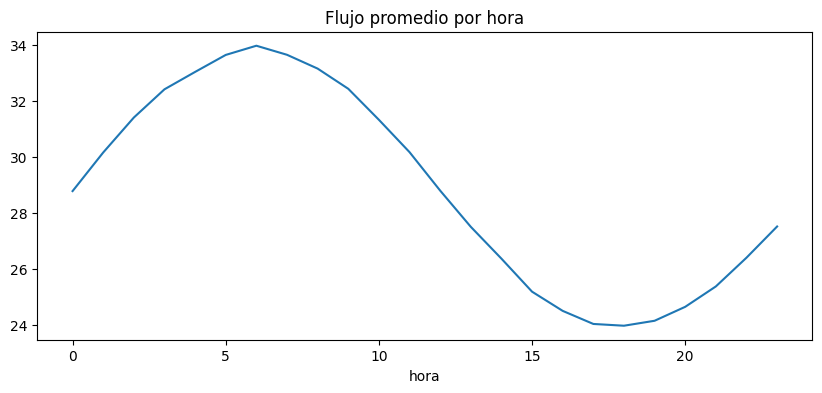

In [62]:
df.groupby("hora")["flujo"].mean().plot(figsize=(10,4))
plt.title("Flujo promedio por hora")
plt.show()

In [ ]:
#standard deviation
df.groupby("tipo_horario")["flujo"].std()

tipo_horario
laboral     9.259694
nocturno    9.353032
Name: flujo, dtype: float64

In [ ]:
#mean (laboral vs nocturno)
df.groupby("tipo_horario")["flujo"].mean()

tipo_horario
laboral     27.953412
nocturno    29.628117
Name: flujo, dtype: float64

In [ ]:
# tipo_horario (column)
df["tipo_horario"] = df["hora"].apply(
    lambda x: "laboral" if 8 <= x <=18
else "nocturno"
)

tipo_horario
laboral     27.953412
nocturno    29.628117
Name: flujo, dtype: float64

In [55]:
df.groupby("hora")["flujo"].std()

hora
0     8.716212
1     8.645190
2     8.674451
3     8.740569
4     8.790129
5     8.846192
6     8.596313
7     8.662896
8     8.734295
9     8.751598
10    8.854888
11    8.624252
12    8.677740
13    8.729089
14    8.568901
15    8.697183
16    8.626199
17    8.499237
18    8.591625
19    8.472555
20    8.530588
21    8.632232
22    8.577375
23    8.758524
Name: flujo, dtype: float64

In [48]:
df["zona"].unique()
#df["zona"].value_counts()
# type(df["flujo"])
# df.columns
#type(df["hora"])

array(['Zona_A', 'Zona_B', 'Zona_C', 'Zona_D'], dtype=object)

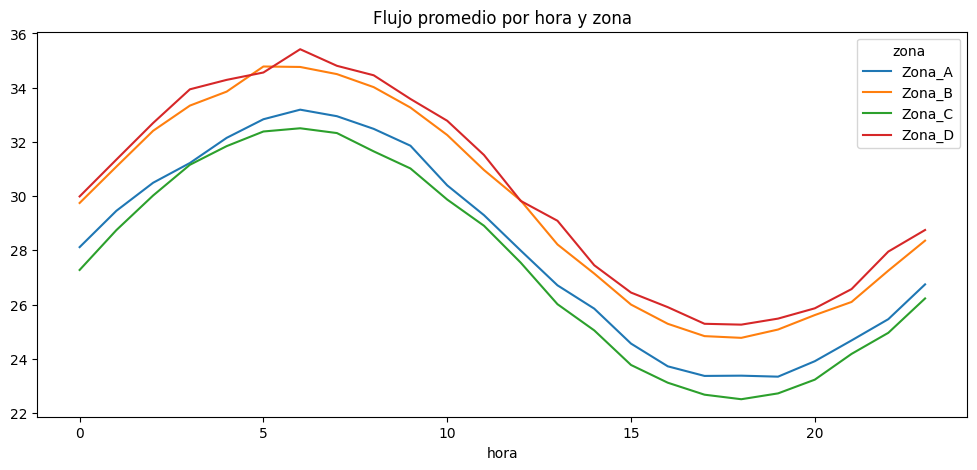

In [ ]:
#group by zones
#df.groupby(["zona","hora"])["flujo"].mean().reset_index()

#group by zones (pivot)
pivot = df.pivot_table(
    values= "flujo",
    index= "hora",
    columns="zona",
    aggfunc="mean"
)
pivot

#group by zones plot

pivot.plot(figsize=(12,5))
plt.title("Flujo promedio por hora y zona")
plt.show()

In [ ]:
#Sensor analysis by hour
df["hora"]=df["timestamp"].dt.hour
df.groupby("hora")["flujo"].mean()

hora
0     28.782298
1     30.159417
2     31.405964
3     32.413476
4     33.033488
5     33.639821
6     33.968167
7     33.644750
8     33.151964
9     32.432024
10    31.325774
11    30.171476
12    28.799631
13    27.507821
14    26.372869
15    25.194119
16    24.509226
17    24.042917
18    23.979714
19    24.156595
20    24.654036
21    25.381452
22    26.406262
23    27.519798
Name: flujo, dtype: float64

In [ ]:
#group by hour
sensor["hora"] = sensor["timestamp"].dt.hour
sensor.groupby("hora")["flujo"].mean()

hora
0     38.676190
1     40.524524
2     41.400952
3     42.126429
4     43.384048
5     43.283333
6     44.245000
7     44.209048
8     43.565000
9     42.929524
10    41.808810
11    40.066429
12    38.335238
13    37.317857
14    36.482381
15    35.691905
16    34.826190
17    34.147143
18    34.427143
19    34.573571
20    34.855476
21    35.539048
22    36.556190
23    37.907381
Name: flujo, dtype: float64

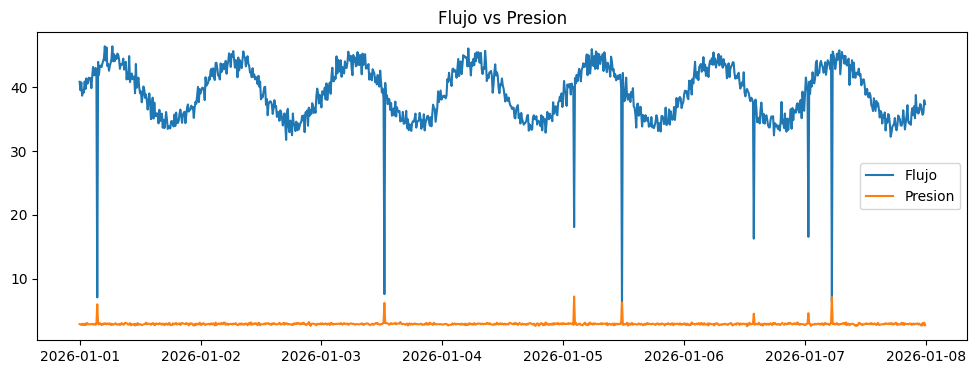

In [ ]:
#flow vs pressure Plot

plt.figure(figsize=(12,4))
plt.plot(sensor["timestamp"],sensor["flujo"], label="Flujo")
plt.plot(sensor["timestamp"],
sensor["presion"], label="Presion")
plt.legend()
plt.title("Flujo vs Presion")
plt.show()

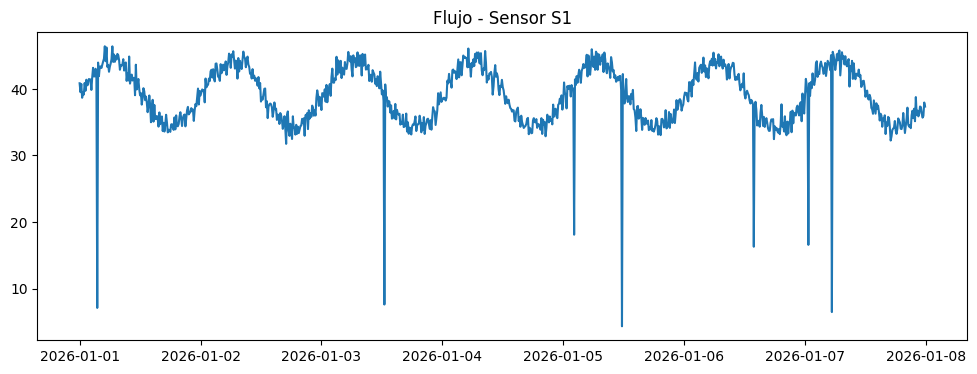

In [ ]:
#flow plot

import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(sensor["timestamp"],sensor["flujo"])
plt.title("Flujo - Sensor S1")
plt.show()


In [ ]:
#Validate data before plotting
len(sensor)
sensor = sensor.sort_values("timestamp")

1008

In [15]:
df["sensor_id"].unique()

array(['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11',
       'S12', 'S13', 'S14', 'S15', 'S16', 'S17', 'S18', 'S19', 'S20'],
      dtype=object)

In [14]:
sensor.shape
sensor.head()

,timestamp,edificio,zona,sensor_id,temperatura,presion,flujo,consumo_kwh


In [ ]:
# selecting a sensor
sensor = df[df["sensor_id"]=="S1"]

In [13]:
df.info()
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20160 entries, 0 to 20159
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   timestamp    20160 non-null  datetime64[ns]
 1   edificio     20160 non-null  object        
 2   zona         20160 non-null  object        
 3   sensor_id    20160 non-null  object        
 4   temperatura  20114 non-null  float64       
 5   presion      20123 non-null  float64       
 6   flujo        20160 non-null  float64       
 7   consumo_kwh  20160 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(3)
memory usage: 1.2+ MB


timestamp      datetime64[ns]
edificio               object
zona                   object
sensor_id              object
temperatura           float64
presion               float64
flujo                 float64
consumo_kwh           float64
dtype: object

In [10]:
df["timestamp"]=pd.to_datetime(df["timestamp"])

In [8]:
df.isnull().sum()

timestamp       0
edificio        0
zona            0
sensor_id       0
temperatura    46
presion        37
flujo           0
consumo_kwh     0
dtype: int64

In [7]:
df.describe()

,temperatura,presion,flujo,consumo_kwh
count,20114.000000,20123.000000,20160.000000,20160.000000
mean,22.275158,2.030490,28.860544,14.394071
std,2.909008,0.560669,9.347459,4.936243
min,13.850000,0.750000,1.080000,2.090000
25%,20.260000,1.610000,21.560000,11.497500
50%,22.290000,1.960000,29.800000,14.775000
75%,24.470000,2.480000,36.422500,17.430000
max,29.790000,7.210000,47.560000,86.290000


In [9]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20160 entries, 0 to 20159
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   timestamp    20160 non-null  object 
 1   edificio     20160 non-null  object 
 2   zona         20160 non-null  object 
 3   sensor_id    20160 non-null  object 
 4   temperatura  20114 non-null  float64
 5   presion      20123 non-null  float64
 6   flujo        20160 non-null  float64
 7   consumo_kwh  20160 non-null  float64
dtypes: float64(4), object(4)
memory usage: 1.2+ MB


In [7]:
import pandas as pd

In [8]:
df = pd.read_csv("../data/raw/sensores_dataset.csv")
df.head()

,timestamp,edificio,zona,sensor_id,temperatura,presion,flujo,consumo_kwh
0,2026-01-01 00:00:00,Edificio_1,Zona_A,S1,20.50,2.88,40.86,14.36
1,2026-01-01 00:10:00,Edificio_1,Zona_A,S1,20.39,2.85,39.52,13.02
2,2026-01-01 00:20:00,Edificio_1,Zona_A,S1,20.17,2.76,40.75,13.87
3,2026-01-01 00:30:00,Edificio_1,Zona_A,S1,20.05,2.94,38.68,13.83
4,2026-01-01 00:40:00,Edificio_1,Zona_A,S1,21.03,2.78,39.49,13.00
